# Support Triage Agent — Batch Run Over All Tickets

Reads `outputs/results/*.json` -- one file per ticket, written by a real
`python -m src.main --all --auto-approve` run against the live Groq API on
**2026-08-15** that pushed all 22 tickets in `data/synthetic_tickets.json`
through the full LangGraph pipeline with the HITL gate auto-approved.

In [1]:
import sys, json, sqlite3
from pathlib import Path

# Works whether Jupyter's cwd is sample_run/ or the repo root.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.config.settings import get_settings
from src.main import load_tickets

settings = get_settings()
tickets_by_id = {t.ticket_id: t for t in load_tickets(settings)}
print(f"Repo root: {REPO_ROOT}")
print(f"Loaded {len(tickets_by_id)} tickets from {settings.tickets_path.relative_to(REPO_ROOT)}")

results_dir = settings.results_dir
result_files = sorted(results_dir.glob("*.json"))
print(f"{len(result_files)} result files in {results_dir.relative_to(REPO_ROOT)}")

def latest_reviewer_action(ticket_id: str) -> str | None:
    """The result JSON's reviewer_action is only a snapshot of hitl_gate's
    output the moment the graph run finished -- None whenever the ticket went
    into the async reviewer queue instead of being auto-approved. The reviews
    table in outputs/databases/triage.db gets updated in place once a human
    (or the CLI's --queue processor) actually reviews it, so pull the most
    recently updated row for this ticket from there instead."""
    conn = sqlite3.connect(settings.reviewer_db_path)
    try:
        row = conn.execute(
            "SELECT reviewer_action FROM reviews WHERE ticket_id = ? ORDER BY updated_at DESC LIMIT 1",
            (ticket_id,),
        ).fetchone()
    finally:
        conn.close()
    return row[0] if row else None

/Users/mahendarprakash/SupportTriageAgent/.supportvenv/lib/python3.14/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Repo root: /Users/mahendarprakash/SupportTriageAgent
Loaded 22 tickets from data/synthetic_tickets.json
22 result files in outputs/results


## Load every ticket's result

In [2]:
import pandas as pd

rows = []
for f in result_files:
    s = json.loads(f.read_text(encoding="utf-8"))
    draft = s.get("draft_reply") or ""
    ticket_id = s["ticket"]["ticket_id"]
    rows.append({
        "ticket_id": ticket_id,
        "category": s["ticket"].get("category"),
        "detected_category": s.get("detected_category"),
        "sentiment": s.get("sentiment"),
        "route_decision": s.get("route_decision"),
        "route_reason": s.get("route_reason"),
        "groundedness_score": s.get("groundedness_score"),
        "llm_groundedness_score": s.get("llm_groundedness_score"),
        "retrieval_attempts": s.get("retrieval_attempts"),
        "has_citation": "[source:" in draft,
        "reviewer_action": latest_reviewer_action(ticket_id),
        "draft_reply_chars": len(draft),
    })

df = pd.DataFrame(rows).sort_values("ticket_id").reset_index(drop=True)
pd.set_option("display.max_colwidth", 40)
df

,ticket_id,category,detected_category,sentiment,route_decision,route_reason,groundedness_score,llm_groundedness_score,retrieval_attempts,has_citation,reviewer_action,draft_reply_chars
0,TCK-1001,refund_request,refund_request,neutral,ESCALATE,low_confidence_after_retries,0.572230,0.95,2,True,APPROVED,933
1,TCK-1002,refund_request,refund_request,negative,ESCALATE,repeat_refund_request_within_window,0.604440,NaN,1,True,APPROVED,814
2,TCK-1003,refund_request,refund_request,negative,ESCALATE,refund_outside_window,0.584357,NaN,1,True,APPROVED,931
3,TCK-1004,subscription_cancellation,subscription_cancellation,neutral,AUTO_RESOLVE,policy_grounded_response,0.606715,1.00,1,True,APPROVED,655
4,TCK-1005,login_access,login_access,neutral,ASK_INFO,missing_required_fields,0.473260,NaN,1,True,APPROVED,1094
5,TCK-1006,login_access,login_access,neutral,ASK_INFO,missing_required_fields,0.598996,NaN,1,True,APPROVED,493
6,TCK-1007,troubleshooting,troubleshooting,negative,ASK_INFO,classifier_requires_more_info,0.311817,NaN,1,True,APPROVED,1222
7,TCK-1008,troubleshooting,refund_request,negative,ESCALATE,refund_outside_window,0.472145,NaN,1,True,APPROVED,1030
8,TCK-1009,abusive_content,other,abusive,REFUSE,abusive_content_detected,0.215538,NaN,1,False,APPROVED,50
9,TCK-1010,abusive_content,refund_request,negative,REFUSE,refund_abuse_language_detected,0.632945,NaN,1,False,APPROVED,80


## Route decision distribution

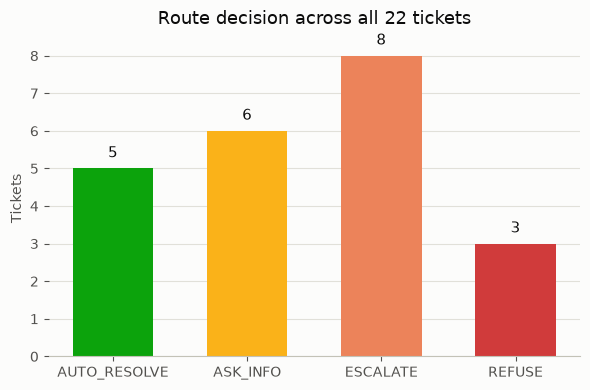

In [3]:
import matplotlib.pyplot as plt

# Status palette: route decisions are literally system states, so they map
# 1:1 onto the good/warning/serious/critical roles rather than an arbitrary
# categorical hue.
ROUTE_COLORS = {
    "AUTO_RESOLVE": "#0ca30c",  # good
    "ASK_INFO": "#fab219",      # warning
    "ESCALATE": "#ec835a",      # serious
    "REFUSE": "#d03b3b",        # critical
}
ROUTE_ORDER = ["AUTO_RESOLVE", "ASK_INFO", "ESCALATE", "REFUSE"]

counts = df["route_decision"].value_counts().reindex(ROUTE_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
bars = ax.bar(counts.index, counts.values, color=[ROUTE_COLORS[r] for r in counts.index], width=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2, str(val),
            ha="center", va="bottom", color="#0b0b0b", fontsize=11)
ax.set_title(f"Route decision across all {len(df)} tickets", color="#0b0b0b", fontsize=13, pad=12)
ax.set_ylabel("Tickets", color="#52514e")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Sentiment distribution

One measure across categories, so all bars share a single hue -- color doesn't need to vary per bar since the x-axis already identifies each sentiment.

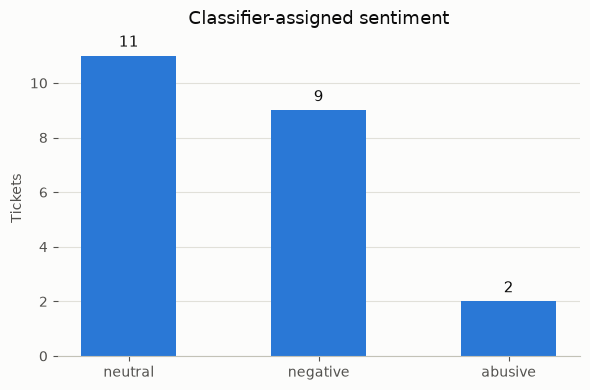

In [4]:
sentiment_counts = df["sentiment"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
bars = ax.bar(sentiment_counts.index, sentiment_counts.values, color="#2a78d6", width=0.5)
for bar, val in zip(bars, sentiment_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2, str(val),
            ha="center", va="bottom", color="#0b0b0b", fontsize=11)
ax.set_title("Classifier-assigned sentiment", color="#0b0b0b", fontsize=13, pad=12)
ax.set_ylabel("Tickets", color="#52514e")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Route reason breakdown

Which specific rule or LLM signal (from `route_decision`'s fixed precedence order in `ARCHITECTURE.md` §4.5) actually fired.

In [5]:
df["route_reason"].value_counts().to_frame("tickets")

,tickets
route_reason,
policy_grounded_response,5
missing_required_fields,4
refund_outside_window,3
classifier_requires_more_info,2
abusive_content_detected,2
low_groundedness,2
low_confidence_after_retries,1
repeat_refund_request_within_window,1
refund_abuse_language_detected,1


## Sample drafted replies

A couple of `AUTO_RESOLVE` drafts -- note the `[source: ...]` citations, each one traceable back to a real chunk in `data/knowledge_base/`.

In [6]:
for f in result_files:
    s = json.loads(f.read_text(encoding="utf-8"))
    if s.get("route_decision") != "AUTO_RESOLVE":
        continue
    print(f"--- {s['ticket']['ticket_id']} ({s['ticket']['subject']}) ---")
    print(s.get("draft_reply"))
    print()

--- TCK-1004 (Cancel my subscription) ---
Draft Reply:

Dear Customer,

Thank you for reaching out to cancel your subscription. According to our subscription policy [source: subscription_policy.md], cancellation requests are effective at the end of the current billing period unless otherwise stated by the account settings. We will process your cancellation request for subscription SUB-4410, and it will be effective at the end of your current billing period.

Please note that as per our policy [source: subscription_policy.md], no refund is guaranteed for the current billing period. If you have any further questions or concerns, please don't hesitate to reach out.

Best regards,
[Your Name]

--- TCK-1011 (Refund exactly 7 days after purchase) ---
Draft Reply:

Dear Customer,

Thank you for reaching out to us regarding your refund request for order ORD-4410. According to our refund policy [source: refund_policy.md], refund requests are accepted only within 7 days of the original purchase 

## Where this data lives on disk

In [7]:
drafted_dir = settings.drafted_replies_dir
print(f"{results_dir.relative_to(REPO_ROOT)}: {len(list(results_dir.glob('*.json')))} files")
print(f"{drafted_dir.relative_to(REPO_ROOT)}: {len(list(drafted_dir.glob('*.txt')))} files")

outputs/results: 22 files
outputs/drafted_replies: 22 files
